In [1]:
import torch
torch.cuda.empty_cache()

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.weight', 'pooler.dense.weight', 'classifier.bias', 'pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


device: cuda


  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

...

  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

  0%|          | 0/351 [00:00<?, ?it/s]

DeBERTa testset size: 700
DeBERTa:
Confusion Matrix:
[[0.92471042 0.03846154]
 [0.07528958 0.96153846]]

Accuracy: 0.9342857142857143
Precision: 0.9247104247104247
Recall: 0.98559670781893
F1 Score: 0.9541832669322708


(0.9342857142857143, 0.9247104247104247, 0.98559670781893, 0.9541832669322708)

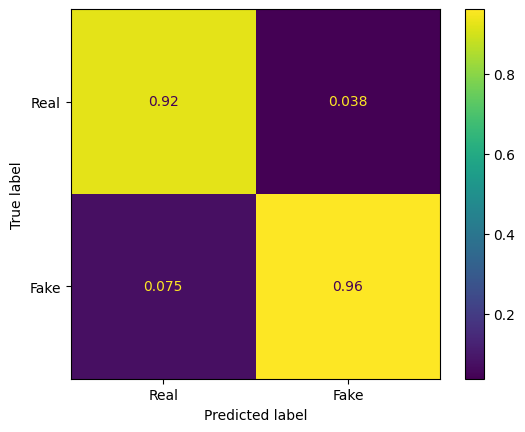

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import DebertaForSequenceClassification, DebertaTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm
from IPython.display import display, clear_output

class FakeNewsDatasetLIAR(Dataset):
    def __init__(self, mode, tokenizer, path):
        assert mode in ['trainset', 'testset']
        self.mode = mode
        self.df = pd.read_csv(path + mode + '.tsv', sep='\t').fillna('')
        self.len = len(self.df)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        label, statement = self.df.iloc[idx, :].values
        label_tensor = torch.tensor(label)

        word_pieces = ['<s>']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['</s>']
        len_st = len(word_pieces)

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len

def create_mini_batch(samples):
    tokens_tensors = [s[0][:512] for s in samples]
    segments_tensors = [s[1][:512] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # zero padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True, padding_value=0)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True, padding_value=0)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0, 1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids

BATCH_SIZE = 8
MODEL_NAME = 'microsoft/deberta-base'
tokenizer = DebertaTokenizer.from_pretrained(MODEL_NAME)

NUM_LABELS = 2
model = DebertaForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS)


# Your training and fine-tuning code remains unchanged
trainset = FakeNewsDatasetLIAR('trainset', tokenizer=tokenizer, path='./')
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model.to(device)

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0

    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()

        outputs = model(input_ids=tokens_tensors,
                        token_type_ids=segments_tensors,
                        attention_mask=masks_tensors,
                        labels=labels)

        loss = outputs[0]
        loss.backward()
        optimizer.step()

        logits = outputs[1]
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist(), labels.cpu().tolist())

        train_loss += loss.item()

        loop.set_description(f'Epoch [{epoch + 1}/{NUM_EPOCHS}]')
        loop.set_postfix(acc=train_acc, loss=train_loss/(batch_idx+1))

def evaluate(testloader):
    true = []
    predictions = []
    with torch.no_grad():
        model.eval()
        for data in testloader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data if t is not None]

            tokens_tensors, segments_tensors, masks_tensors = data[:3]
            test_outputs = model(input_ids=tokens_tensors,
                                 token_type_ids=segments_tensors,
                                 attention_mask=masks_tensors)

            logits = test_outputs.logits
            _, pred = torch.max(logits.data, 1)

            labels = data[3]
            true.extend(labels.cpu().tolist())
            predictions.extend(pred.cpu().tolist())

    cm = confusion_matrix(true, predictions, labels=[1, 0], normalize='pred')
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot()

    accuracy = accuracy_score(true, predictions)
    precision = precision_score(true, predictions)
    recall = recall_score(true, predictions)
    f1 = f1_score(true, predictions)

    print('\nAccuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1 Score:', f1)

    return accuracy, precision, recall, f1


# Example usage:
testset_deberta = FakeNewsDatasetLIAR('testset', tokenizer=tokenizer, path='./')
print('DeBERTa testset size:', testset_deberta.__len__())
testloader_deberta = DataLoader(testset_deberta, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

print('DeBERTa:')
print('Confusion Matrix:')
evaluate(testloader_deberta)